<a href="https://colab.research.google.com/github/Sophie-melon/Medlytics_2026/blob/main/SVM_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Exercises

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [ ]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

data = pd.read_csv(url, names = names)

Split data into training, colidation, and test sets with a test size of 25%

In [ ]:
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

y_col = 'class'

test_size = 0.35
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size = test_size, random_state = 100)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = test_size, random_state = 100)


Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [ ]:
svm_model = SVC(gamma = 0.01)

svm_model.fit(X_train, y_train)

SVC(gamma=0.01)

Print accuracy of training and validation data

In [18]:
y_train_pred = svm_model.predict(X_train)
print("Training accuracy is: ", accuracy_score(y_train, y_train_pred)*100, "%")

y_val_pred = svm_model.predict(X_val)
print("Validation accuracy is: ", accuracy_score(y_val, y_val_pred)*100, "%")

Training accuracy is:  100.0 %
Validation accuracy is:  65.27777777777779 %


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [ ]:
svm_model2 = SVC(gamma = 0.001)
svm_model2.fit(X_train, y_train)

SVC(gamma=0.001)

Print accuracy of training and validation data

In [19]:
y_train_pred2 = svm_model2.predict(X_train)
print("Training accuracy is: ", accuracy_score(y_train, y_train_pred2)*100, "%")

y_val_pred2 = svm_model2.predict(X_val)
print("Validation accuracy is: ", accuracy_score(y_val, y_val_pred2)*100, "%")

Training accuracy is:  84.72222222222221 %
Validation accuracy is:  70.13888888888889 %


Explain the accuracy results below.

the training accuracy was lower, but the validation accuracy was higher, so since the model is considering the overall picture of things and considering more points, the model is more accurate, but probably a more middle gamma will yeild a better value of accuracy

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

High Gamma Confusion Matrix
[[94  0]
 [50  0]]
low gamma cm
[[79 15]
 [28 22]]


/tmp/ipykernel_765/3727812222.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_765/3727812222.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


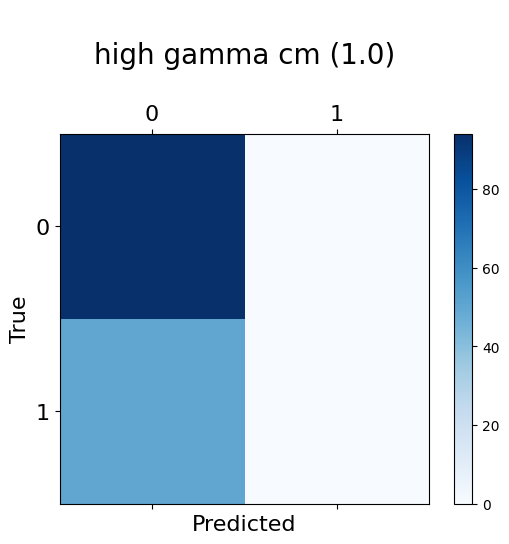

/tmp/ipykernel_765/3727812222.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + labels, fontsize=16)
/tmp/ipykernel_765/3727812222.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + labels, fontsize=16)


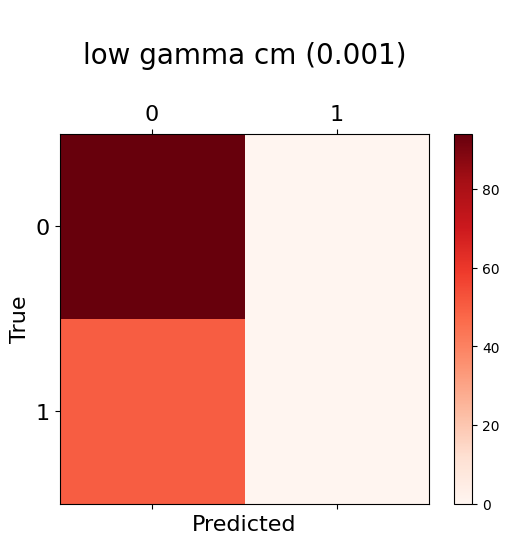

In [29]:
from sklearn.metrics import confusion_matrix

cm_high = confusion_matrix(y_val, y_val_pred)
cm_low = confusion_matrix(y_val, y_val_pred2)

print("High Gamma Confusion Matrix")
print(cm_high)
print("low gamma cm")
print(cm_low)

def plot_cmatrix(cm,labels, color, title='Confusion Matrix'):
  fig = plt.figure()
  ax = fig.add_subplot(111)
  cax = ax.matshow(cm,cmap=color)
  plt.title('\n'+title+'\n', fontsize=20)
  fig.colorbar(cax)
  ax.set_xticklabels([''] + labels, fontsize=16)
  ax.set_yticklabels([''] + labels, fontsize=16)
  plt.xlabel('Predicted', fontsize=16)
  plt.ylabel('True', fontsize=16)
  plt.show()

labels = [0,1]
plot_cmatrix(cm_high,labels, "Blues", title = "high gamma cm (1.0)")

plot_cmatrix(cm_high,labels,"Reds", title = "low gamma cm (0.001)")







